# Notebook 2 (v2): Improved Baseline 2D U-Net — MSD Liver

### Changes vs baseline
| Area | Baseline | v2 |
|---|---|---|
| Input channels | 1 (single slice) | **3 (2.5D triplet)** |
| Epochs | 5 | **50 (full run, no early stopping)** |
| Train/val split | Random slice-level | **Patient-level (no leakage)** |
| Augmentation | None | **Flips, rotation, intensity jitter** |
| Loss | CE + Dice (equal weight) | **Focal + Dice (class-weighted)** |
| LR schedule | None | **Cosine annealing** |
| Regularisation | None | **Dropout (p=0.2) in bottleneck** |
| Evaluation | Dice on val batches | **Full per-volume Dice** |


In [1]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

## 1. Imports & Device Setup

In [2]:
import os, json, random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 3. Paths & Hyperparameters

Update the paths at the top of the cell below to point to wherever Notebook 1 wrote its cache on your machine.


In [3]:
# ---- Update these paths to match your local setup ----
CACHE_ROOT = r"msd_liver_cache_v2"
IMG_CACHE  = os.path.join(CACHE_ROOT, "images")
MSK_CACHE  = os.path.join(CACHE_ROOT, "masks")
SPLIT_FILE = os.path.join(CACHE_ROOT, "patient_split.json")

# ---- Output dirs ----
CHECKPOINT_DIR = r"checkpoints_v2"
FIG_DIR        = r"figures_v2"
for d in [CHECKPOINT_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

# ---- Hyperparameters ----
NUM_CLASSES   = 3       # 0=background, 1=liver, 2=tumor
IN_CHANNELS   = 3       # 2.5D triplet
BATCH_SIZE    = 8
EPOCHS        = 100
LR            = 1e-4
FOCAL_GAMMA   = 2.0

# Class weights: background, liver, tumor
CLASS_WEIGHTS = torch.tensor([0.1, 1.0, 5.0], device=device)

print("Config ready.")


Config ready.


C:\Users\DYPIU\AppData\Local\Temp\ipykernel_2080\3143108355.py:22: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:39.)
  CLASS_WEIGHTS = torch.tensor([0.1, 1.0, 5.0], device=device)


## 4. Load Patient-Level Split

In [4]:
with open(SPLIT_FILE) as fh:
    split = json.load(fh)

train_vols = set(f.replace(".nii.gz", ".npy") for f in split["train"])
val_vols   = set(f.replace(".nii.gz", ".npy") for f in split["val"])

# Filter to .npy only — avoids picking up .ipynb_checkpoints or other folders
all_npy = set(f for f in os.listdir(IMG_CACHE) if f.endswith(".npy"))

def build_samples(vol_set):
    samples = []
    for f in sorted(vol_set & all_npy):
        arr = np.load(os.path.join(IMG_CACHE, f), mmap_mode="r")
        for i in range(arr.shape[0]):
            samples.append((f, i))
    return samples

train_samples = build_samples(train_vols)
val_samples   = build_samples(val_vols)

print(f"Train slices : {len(train_samples)}")
print(f"Val slices   : {len(val_samples)}")


Train slices : 18122
Val slices   : 4985


## 5. Dataset with Augmentation

Augmentation is applied **only during training** via `augment=True`.

| Transform | Details |
|---|---|
| Random horizontal flip | p=0.5 |
| Random vertical flip | p=0.5 |
| Random 90° rotation | p=0.5 |
| Intensity jitter | ±10 % brightness, ±10 % contrast |

All spatial transforms are applied consistently to both the image and its mask.

In [5]:
class CachedLiverDataset(Dataset):
    def __init__(self, samples, img_dir, mask_dir, augment=False):
        self.samples  = samples
        self.augment  = augment
        # Memory-map all files up front for fast random access
        self.img_mm  = {}
        self.mask_mm = {}
        for f, _ in samples:
            if f not in self.img_mm:
                self.img_mm[f]  = np.load(os.path.join(img_dir,  f), mmap_mode="r")
                self.mask_mm[f] = np.load(os.path.join(mask_dir, f), mmap_mode="r")

    def __len__(self):
        return len(self.samples)

    def _augment(self, img, mask):
        """img: (3,H,W) float32  mask: (H,W) uint8"""
        # Horizontal flip
        if random.random() < 0.5:
            img  = img[:, :, ::-1].copy()
            mask = mask[:, ::-1].copy()
        # Vertical flip
        if random.random() < 0.5:
            img  = img[:, ::-1, :].copy()
            mask = mask[::-1, :].copy()
        # 90-degree rotation
        if random.random() < 0.5:
            k = random.randint(1, 3)
            img  = np.rot90(img,  k, axes=(1, 2)).copy()
            mask = np.rot90(mask, k, axes=(0, 1)).copy()
        # Intensity jitter (applied per-channel independently)
        alpha = 1.0 + random.uniform(-0.10, 0.10)  # contrast
        beta  = random.uniform(-0.10, 0.10)         # brightness
        img   = np.clip(img * alpha + beta, img.min(), img.max())
        return img, mask

    def __getitem__(self, idx):
        f, i = self.samples[idx]
        # cast to float32 here regardless of whether file was saved as float16 or float32
        img  = np.array(self.img_mm[f][i],  dtype=np.float32)
        mask = np.array(self.mask_mm[f][i], dtype=np.uint8)
    
        if self.augment:
            img, mask = self._augment(img, mask)
    
        return (torch.from_numpy(img).float(),
                torch.from_numpy(mask).long())

## 6. DataLoaders

In [6]:
train_ds = CachedLiverDataset(train_samples, IMG_CACHE, MSK_CACHE, augment=True)
val_ds   = CachedLiverDataset(val_samples,   IMG_CACHE, MSK_CACHE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,
                          num_workers=0,   # must be 0 on Windows
                          pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False,
                          num_workers=0,   # must be 0 on Windows
                          pin_memory=True)

imgs, masks = next(iter(train_loader))
print("Image batch :", imgs.shape)   # (B, 3, 256, 256)
print("Mask batch  :", masks.shape)  # (B, 256, 256)
print("Classes     :", torch.unique(masks).tolist())


Image batch : torch.Size([8, 3, 256, 256])
Mask batch  : torch.Size([8, 256, 256])
Classes     : [0, 1, 2]


## 6b. Augmentation Visualisation

For each of the 4 augmentations applied during training, we show the **original vs augmented** CT centre slice and mask side-by-side so you can visually confirm each transform is working correctly and the mask stays aligned.

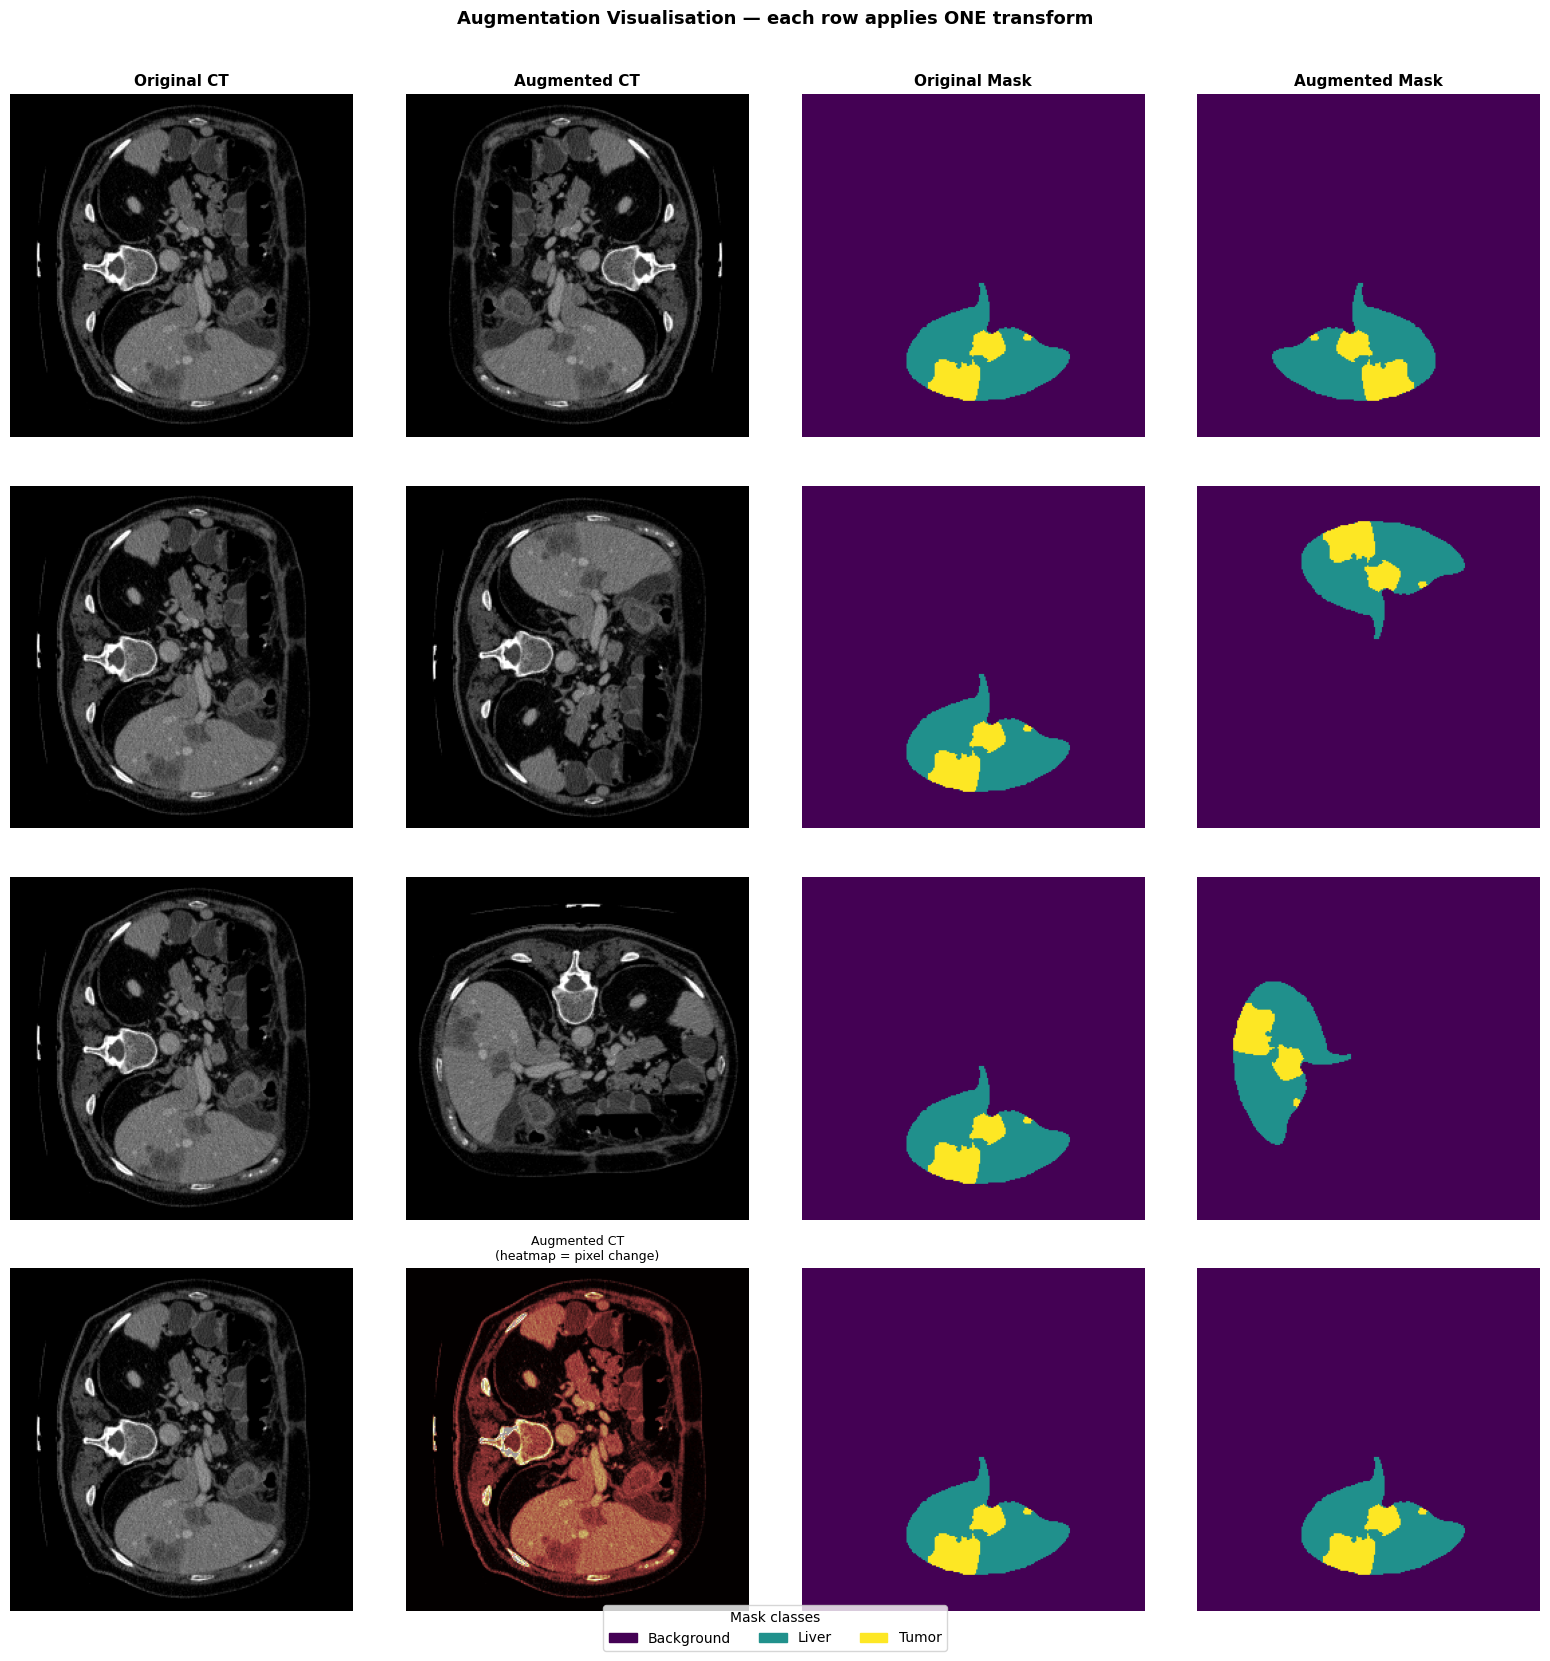

Saved → figures_v2/augmentation_visualisation.png


In [7]:
import random
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ------------------------------------------------------------------ #
# Grab one real sample from the training set (no augmentation yet)
# ------------------------------------------------------------------ #
sample_idx = next(
    i for i in random.sample(range(len(train_ds)), len(train_ds))
    if (train_ds[i][1] == 2).any()
)
raw_ds = CachedLiverDataset([train_samples[sample_idx]],
                             IMG_CACHE, MSK_CACHE, augment=False)
img_orig, mask_orig = raw_ds[0]          # tensors
img_np   = img_orig.numpy()              # (3, H, W)
mask_np  = mask_orig.numpy()             # (H, W)

# ------------------------------------------------------------------ #
# Apply each augmentation individually so we can show them separately
# ------------------------------------------------------------------ #
def apply_single_aug(img, mask, aug_name):
    """Return (aug_img, aug_mask) with only the named transform applied."""
    img  = img.copy()
    mask = mask.copy()

    if aug_name == 'H-Flip':
        img  = img[:, :, ::-1].copy()
        mask = mask[:, ::-1].copy()

    elif aug_name == 'V-Flip':
        img  = img[:, ::-1, :].copy()
        mask = mask[::-1, :].copy()

    elif aug_name == 'Rotation 90°':
        k = random.choice([1, 2, 3])
        img  = np.rot90(img,  k, axes=(1, 2)).copy()
        mask = np.rot90(mask, k, axes=(0, 1)).copy()

    elif aug_name == 'Intensity Jitter':
        alpha = 1.0 + random.uniform(-0.10, 0.10)
        beta  = random.uniform(-0.10, 0.10)
        img   = np.clip(img * alpha + beta, img.min(), img.max())

    return img, mask

# ------------------------------------------------------------------ #
# Plot: one row per augmentation  |  col0=original  col1=augmented
#       col2=original mask        col3=augmented mask
# ------------------------------------------------------------------ #
aug_names = ['H-Flip', 'V-Flip', 'Rotation 90°', 'Intensity Jitter']
n_rows = len(aug_names)

fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 4))
fig.suptitle('Augmentation Visualisation — each row applies ONE transform',
             fontsize=13, fontweight='bold', y=1.01)

col_titles = ['Original CT', 'Augmented CT', 'Original Mask', 'Augmented Mask']
for ax, t in zip(axes[0], col_titles):
    ax.set_title(t, fontsize=11, fontweight='bold')

# Colormap + legend patches for the mask
cmap_mask = matplotlib.colormaps['viridis'].resampled(3)
legend_patches = [
    mpatches.Patch(color=cmap_mask(0), label='Background'),
    mpatches.Patch(color=cmap_mask(1), label='Liver'),
    mpatches.Patch(color=cmap_mask(2), label='Tumor'),
]

for row, aug_name in enumerate(aug_names):
    aug_img, aug_mask = apply_single_aug(img_np, mask_np, aug_name)

    centre_orig = img_np[1]    # centre channel of triplet
    centre_aug  = aug_img[1]

    # Difference image for intensity jitter to make the change visible
    diff = np.abs(centre_aug - centre_orig)

    axes[row, 0].imshow(centre_orig, cmap='gray')
    axes[row, 0].set_ylabel(aug_name, fontsize=11, fontweight='bold',
                             rotation=90, labelpad=10)

    axes[row, 1].imshow(centre_aug, cmap='gray')

    # If intensity jitter, overlay diff heatmap so change is visible
    if aug_name == 'Intensity Jitter':
        axes[row, 1].imshow(diff, cmap='hot', alpha=0.4)
        axes[row, 1].set_title('Augmented CT\n(heatmap = pixel change)',
                                fontsize=9)

    axes[row, 2].imshow(mask_np,  cmap=cmap_mask, vmin=0, vmax=2)
    axes[row, 3].imshow(aug_mask, cmap=cmap_mask, vmin=0, vmax=2)

    for ax in axes[row]:
        ax.axis('off')

# Single shared legend at the bottom for mask colours
fig.legend(handles=legend_patches, loc='lower center',
           ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02),
           title='Mask classes', title_fontsize=10)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/augmentation_visualisation.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {FIG_DIR}/augmentation_visualisation.png")


## 7. Improved U-Net Architecture

**Changes over baseline:**
- Input channels: 3 (was 1)
- Dropout (p=0.2) added to the bottleneck layer
- Everything else is structurally identical to preserve comparability


In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(p=dropout))
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_ch=3, n_cls=3, dropout=0.2):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_ch,  64)
        self.enc2 = DoubleConv(64,  128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck with dropout
        self.bottleneck = DoubleConv(512, 1024, dropout=dropout)

        # Decoder
        self.up4  = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.dec4 = DoubleConv(1024, 512)
        self.up3  = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec3 = DoubleConv(512, 256)
        self.up2  = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec2 = DoubleConv(256, 128)
        self.up1  = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, n_cls, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1)


model = UNet(in_ch=IN_CHANNELS, n_cls=NUM_CLASSES).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

# Quick shape check
with torch.no_grad():
    out = model(imgs.to(device))
print("Output shape:", out.shape)

Trainable parameters: 31,037,763
Output shape: torch.Size([8, 3, 256, 256])


## 8. Loss Functions

### Focal Loss
Focal Loss down-weights easy (well-classified) pixels so training focuses on hard, class-imbalanced regions like small tumors:

$$FL(p_t) = -\alpha_t(1-p_t)^\gamma \log(p_t)$$

### Combined Loss
`total_loss = FocalLoss + DiceLoss`

Focal handles pixel-level class imbalance; Dice handles regional overlap directly.

In [9]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight

    def forward(self, pred, target):
        # pred: (B, C, H, W)  target: (B, H, W)
        ce    = F.cross_entropy(pred, target, weight=self.weight, reduction="none")
        pt    = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        return focal.mean()


class DiceLoss(nn.Module):
    def forward(self, pred, target, smooth=1e-5):
        prob = torch.softmax(pred, dim=1)
        loss = 0.0
        for c in [1, 2]:   # liver + tumor only
            p = prob[:, c]
            t = (target == c).float()
            loss += 1 - (2*(p*t).sum() + smooth) / (p.sum() + t.sum() + smooth)
        return loss / 2


focal_loss = FocalLoss(gamma=FOCAL_GAMMA, weight=CLASS_WEIGHTS)
dice_loss  = DiceLoss()

def total_loss(pred, target):
    return focal_loss(pred, target) + dice_loss(pred, target)

print("Loss functions ready.")

Loss functions ready.


## 9. Optimizer & LR Scheduler

`CosineAnnealingLR` smoothly decays the learning rate from `LR` → near-zero over `EPOCHS`, allowing finer convergence in later epochs without manual tuning.

In [10]:
# ---- GPU optimisations (RTX 4060 specific) ----
torch.backends.cudnn.benchmark         = True
torch.backends.cudnn.enabled           = True
torch.backends.cuda.matmul.allow_tf32  = True   # tensor cores
torch.backends.cudnn.allow_tf32        = True   # tensor cores

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)

use_amp = device.type == "cuda"
scaler  = torch.amp.GradScaler('cuda', enabled=use_amp)

print("Optimizer        :", type(optimizer).__name__)
print("Scheduler        :", type(scheduler).__name__)
print("AMP enabled      :", use_amp)
print("cuDNN benchmark  :", torch.backends.cudnn.benchmark)
print("TF32 enabled     :", torch.backends.cudnn.allow_tf32)

Optimizer        : Adam
Scheduler        : CosineAnnealingLR
AMP enabled      : True
cuDNN benchmark  : True
TF32 enabled     : True


## 10. Dice Metric (Evaluation)

In [11]:
def dice_metric(pred, target, smooth=1e-5):
    """Returns (liver_dice, tumor_dice) for a batch."""
    pred = torch.argmax(pred, dim=1)
    dices = []
    for c in [1, 2]:
        p = (pred   == c).float()
        t = (target == c).float()
        dice = (2*(p*t).sum() + smooth) / (p.sum() + t.sum() + smooth)
        dices.append(dice.item())
    return dices  # [liver_dice, tumor_dice]

## 11. Training Loop

Runs for the full `EPOCHS` epochs with no early stopping.
The best model (by validation tumor Dice) is saved automatically each time it improves.
Epoch timing is printed live so you can track progress.


In [12]:
import time

RESUME_PATH = os.path.join(CHECKPOINT_DIR, "unet_v2_resume.pth")
BEST_PATH   = os.path.join(CHECKPOINT_DIR, "unet_v2_best.pth")
FINAL_PATH  = os.path.join(CHECKPOINT_DIR, "unet_v2_final.pth")

# ---- Resume from checkpoint if one exists ----
start_epoch     = 1
best_tumor_dice = 0.0
history = {
    "train_loss": [], "val_liver_dice": [], "val_tumor_dice": [],
    "lr": [], "epoch_time": []
}

if os.path.exists(RESUME_PATH):
    checkpoint = torch.load(RESUME_PATH, map_location=device)
    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    scheduler.load_state_dict(checkpoint["scheduler"])
    scaler.load_state_dict(checkpoint["scaler"])
    start_epoch     = checkpoint["epoch"] + 1
    best_tumor_dice = checkpoint["best_tumor_dice"]
    history         = checkpoint["history"]
    print(f"▶️  Resumed from epoch {checkpoint['epoch']}  "
          f"(best tumor Dice so far: {best_tumor_dice:.4f})")
else:
    print("🆕 Starting fresh training run.")

def fmt_time(secs):
    h, m = divmod(int(secs), 3600)
    m, s = divmod(m, 60)
    return f"{h:02d}h {m:02d}m {s:02d}s"

training_start = time.time()

for epoch in range(start_epoch, EPOCHS + 1):
    epoch_start = time.time()

    # ---- Train ----
    model.train()
    train_loss = 0.0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda', enabled=use_amp):
            preds = model(imgs)
            loss  = total_loss(preds, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    # ---- Validate ----
    model.eval()
    liver_dice = tumor_dice = 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            d_l, d_t = dice_metric(preds, masks)
            liver_dice += d_l
            tumor_dice += d_t

    liver_dice /= len(val_loader)
    tumor_dice /= len(val_loader)

    # ---- Timing ----
    epoch_secs    = time.time() - epoch_start
    elapsed_total = time.time() - training_start
    epochs_left   = EPOCHS - epoch
    avg_epoch_time = elapsed_total / (epoch - start_epoch + 1)
    eta_secs      = avg_epoch_time * epochs_left

    # ---- Logging ----
    history["train_loss"].append(train_loss)
    history["val_liver_dice"].append(liver_dice)
    history["val_tumor_dice"].append(tumor_dice)
    history["lr"].append(current_lr)
    history["epoch_time"].append(epoch_secs)

    print(f"Ep {epoch:>3}/{EPOCHS}  "
          f"loss={train_loss:.4f}  "
          f"liver={liver_dice:.4f}  "
          f"tumor={tumor_dice:.4f}  "
          f"lr={current_lr:.2e}  "
          f"⏱ {fmt_time(epoch_secs)}/ep  "
          f"ETA {fmt_time(eta_secs)}")

    # ---- Save best model ----
    if tumor_dice > best_tumor_dice:
        best_tumor_dice = tumor_dice
        torch.save(model.state_dict(), BEST_PATH)
        print(f"  ✅ Best model saved  (tumor Dice={best_tumor_dice:.4f})")

    # ---- Save resume checkpoint every epoch ----
    torch.save({
        "epoch"           : epoch,
        "model"           : model.state_dict(),
        "optimizer"       : optimizer.state_dict(),
        "scheduler"       : scheduler.state_dict(),
        "scaler"          : scaler.state_dict(),
        "best_tumor_dice" : best_tumor_dice,
        "history"         : history,
    }, RESUME_PATH)

# ---- Training complete ----
total_time = time.time() - training_start
torch.save(model.state_dict(), FINAL_PATH)
print(f"\n🎉 Training complete in {fmt_time(total_time)}")
print(f"   Avg time / epoch : {fmt_time(avg_epoch_time)}")
print(f"   Best tumor Dice  : {best_tumor_dice:.4f}")
print(f"   Best    → {BEST_PATH}")
print(f"   Final   → {FINAL_PATH}")
print(f"   Resume  → {RESUME_PATH}  (safe to delete after training)")


▶️  Resumed from epoch 55  (best tumor Dice so far: 0.6947)
Ep  56/100  loss=0.1317  liver=0.8399  tumor=0.6644  lr=4.48e-06  ⏱ 00h 09m 26s/ep  ETA 06h 55m 42s
Ep  57/100  loss=0.1309  liver=0.8408  tumor=0.6402  lr=5.71e-06  ⏱ 00h 07m 59s/ep  ETA 06h 15m 32s
Ep  58/100  loss=0.1314  liver=0.8412  tumor=0.6661  lr=7.12e-06  ⏱ 00h 07m 59s/ep  ETA 05h 56m 43s
Ep  59/100  loss=0.1306  liver=0.8386  tumor=0.6815  lr=8.71e-06  ⏱ 00h 07m 58s/ep  ETA 05h 43m 07s
Ep  60/100  loss=0.1310  liver=0.8339  tumor=0.6694  lr=1.05e-05  ⏱ 00h 07m 58s/ep  ETA 05h 31m 46s
Ep  61/100  loss=0.1315  liver=0.8481  tumor=0.6890  lr=1.24e-05  ⏱ 00h 08m 07s/ep  ETA 05h 22m 26s
Ep  62/100  loss=0.1326  liver=0.8118  tumor=0.6246  lr=1.44e-05  ⏱ 00h 08m 08s/ep  ETA 05h 13m 44s
Ep  63/100  loss=0.1309  liver=0.8335  tumor=0.6774  lr=1.66e-05  ⏱ 00h 07m 59s/ep  ETA 05h 04m 19s
Ep  64/100  loss=0.1352  liver=0.8263  tumor=0.6592  lr=1.89e-05  ⏱ 00h 07m 58s/ep  ETA 04h 55m 09s
Ep  65/100  loss=0.1373  liver=0.8470  t

## 12. Training Curves

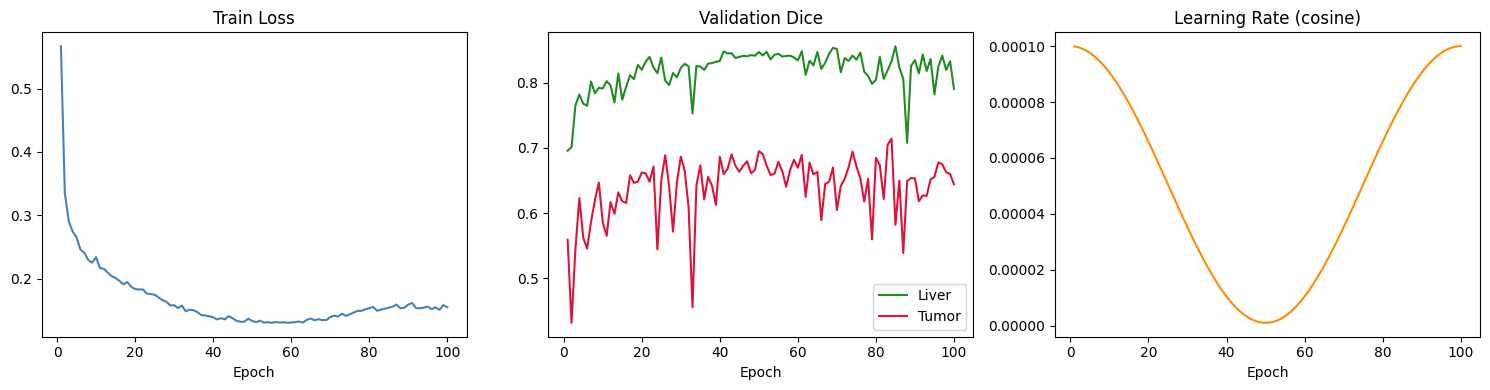

In [13]:
epochs_ran = len(history["train_loss"])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(x, history["train_loss"], color="steelblue")
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")

axes[1].plot(x, history["val_liver_dice"], label="Liver", color="forestgreen")
axes[1].plot(x, history["val_tumor_dice"], label="Tumor", color="crimson")
axes[1].set_title("Validation Dice")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(x, history["lr"], color="darkorange")
axes[2].set_title("Learning Rate (cosine)")
axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/training_curves_v2.png", dpi=150)
plt.show()

## 13. Load Best Model & Qualitative Evaluation

In [14]:
model.load_state_dict(torch.load(BEST_PATH, map_location=device))
model.eval()
print("✅ Best model loaded.")

✅ Best model loaded.


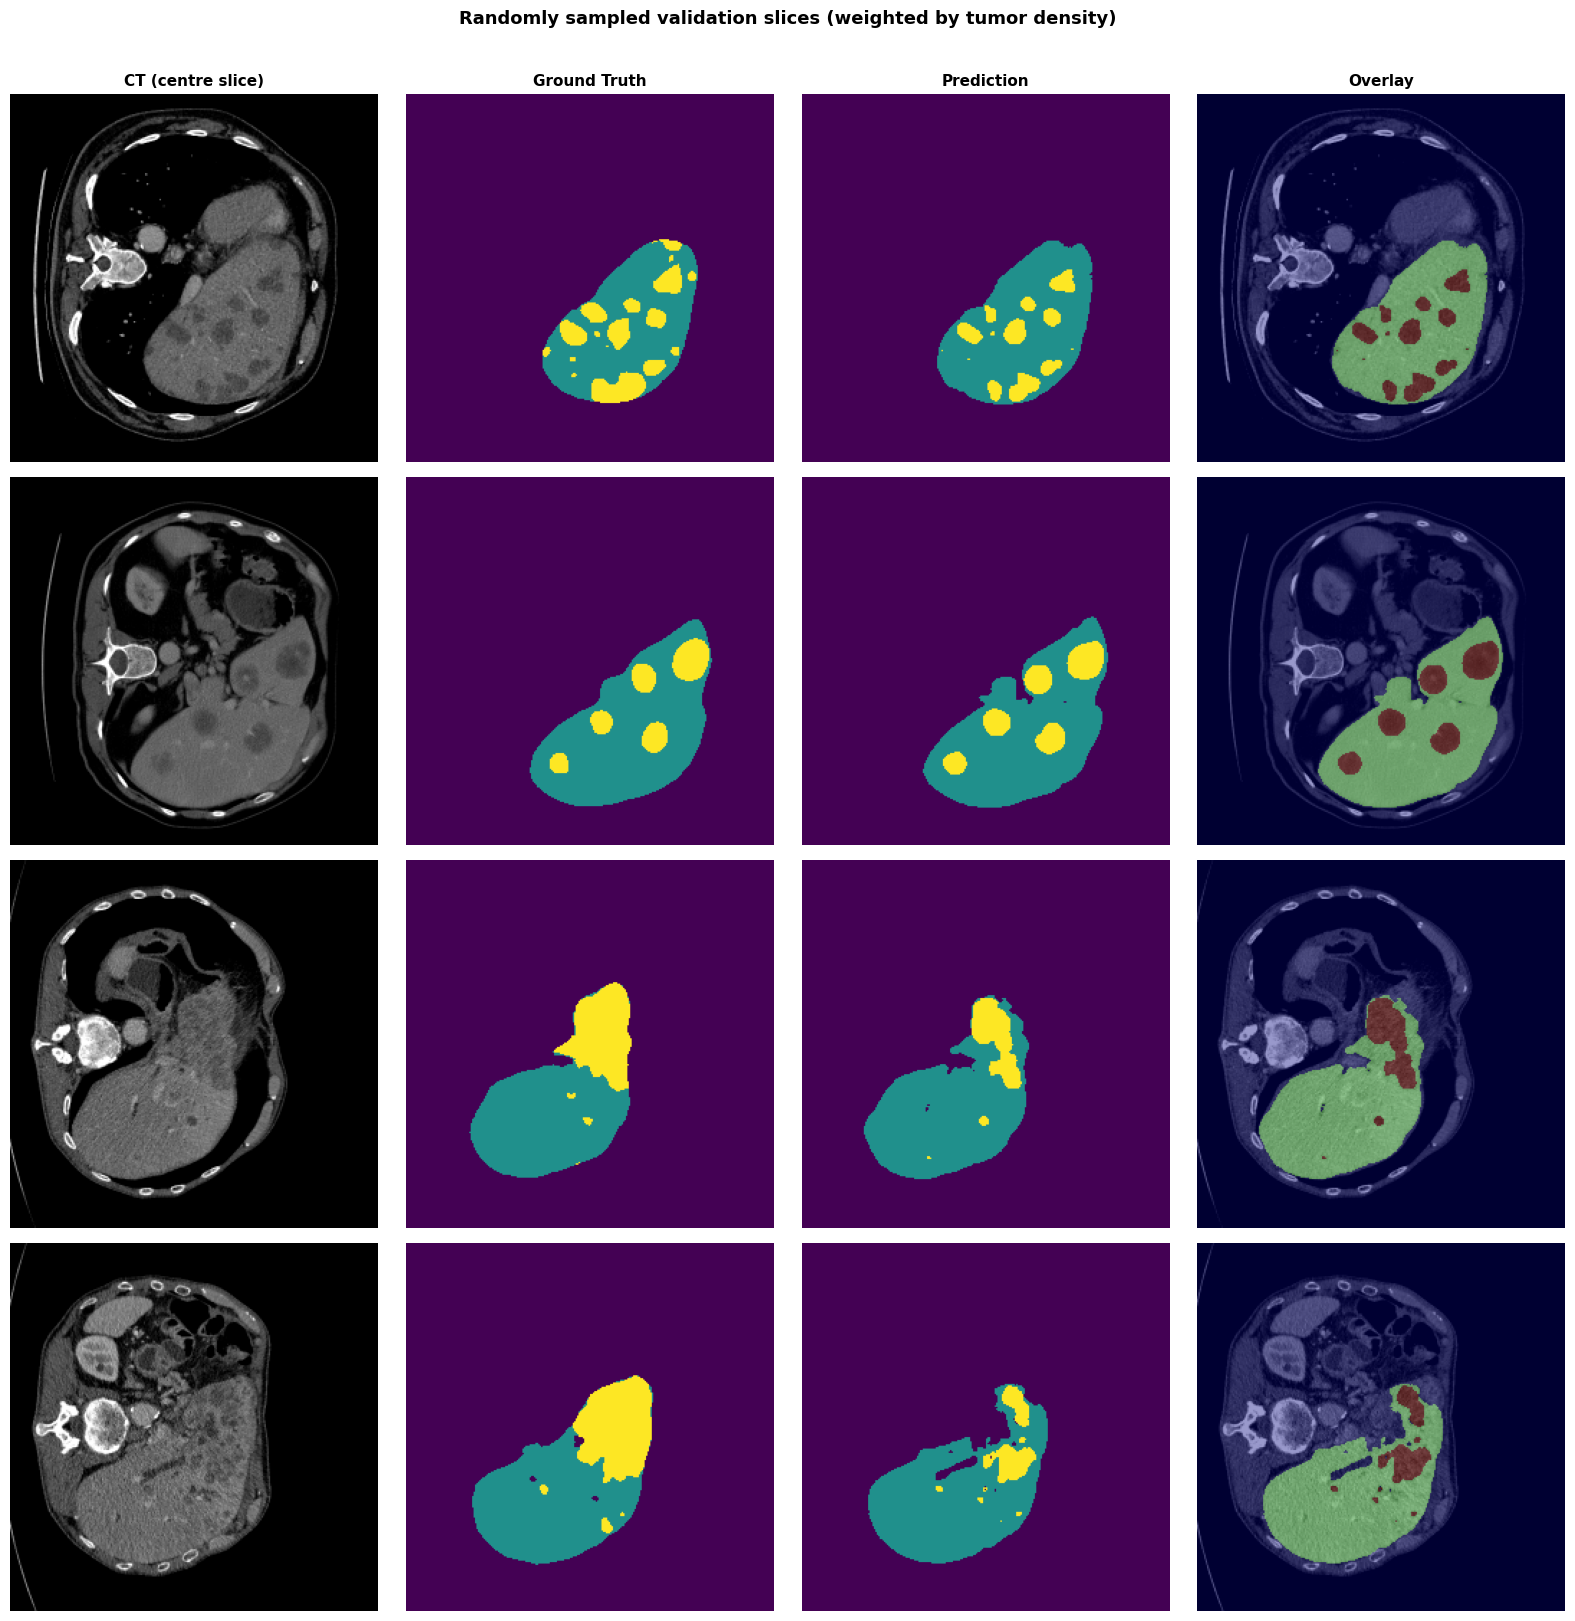

In [15]:
def visualize_predictions(model, dataset, n=4, tag="val"):
    model.eval()

    # ---- Weighted random sample — prefers tumor-dense slices but not strictly top-n ----
    tumor_counts = []
    indices_with_tumor = []

    for idx in range(len(dataset)):
        _, gt = dataset[idx]
        tumor_px = (gt == 2).sum().item()
        if tumor_px > 0:
            indices_with_tumor.append(idx)
            tumor_counts.append(tumor_px)

    # Use tumor pixel count as sampling weight — denser = more likely, but still random
    weights = np.array(tumor_counts, dtype=np.float32)
    weights /= weights.sum()
    chosen = np.random.choice(indices_with_tumor, size=n, replace=False, p=weights)

    fig, axes = plt.subplots(n, 4, figsize=(16, n * 4))
    col_titles = ["CT (centre slice)", "Ground Truth", "Prediction", "Overlay"]
    for ax, t in zip(axes[0], col_titles):
        ax.set_title(t, fontsize=11, fontweight="bold")

    for row, idx in enumerate(chosen):
        img, gt = dataset[idx]

        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(device))
            pred = torch.argmax(pred, dim=1).cpu().squeeze().numpy()

        ct_disp = img[1].numpy()
        gt_np   = gt.numpy()

        axes[row, 0].imshow(ct_disp, cmap="gray")
        axes[row, 1].imshow(gt_np,   cmap="viridis", vmin=0, vmax=2)
        axes[row, 2].imshow(pred,    cmap="viridis", vmin=0, vmax=2)
        axes[row, 3].imshow(ct_disp, cmap="gray")
        axes[row, 3].imshow(pred,    cmap="jet", alpha=0.4, vmin=0, vmax=2)

        for ax in axes[row]:
            ax.axis("off")

    plt.suptitle(f"Randomly sampled validation slices (weighted by tumor density)",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/qualitative_{tag}_v2.png", dpi=150, bbox_inches="tight")
    plt.show()

visualize_predictions(model, val_ds, n=4, tag="val")

## 14. Final Dice Report

In [16]:
model.eval()
all_liver, all_tumor = [], []

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        d_l, d_t = dice_metric(preds, masks)
        all_liver.append(d_l)
        all_tumor.append(d_t)

print("=============================")
print(" Final Validation Dice Report")
print("=============================")
print(f" Liver Dice : {np.mean(all_liver):.4f} ± {np.std(all_liver):.4f}")
print(f" Tumor Dice : {np.mean(all_tumor):.4f} ± {np.std(all_tumor):.4f}")
print("=============================")

 Final Validation Dice Report
 Liver Dice : 0.8327 ± 0.2835
 Tumor Dice : 0.7139 ± 0.3988
